In [1]:
# Importações
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/carara/.local/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/carara/.local/lib/python3.10/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/home/carara/.local/lib/python3.10/site-pac

AttributeError: _ARRAY_API not found

In [2]:
# Leitura do arquivo CSV
df = pd.read_csv("06 - Dados - Social Network Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
# Converter 'Gender' para valores numéricos
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

# Verificar os dados após a conversão
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0


In [4]:
# Separar variáveis independentes (X) e alvo (y)
X = df[['Gender', 'Age', 'EstimatedSalary']]
y = df['Purchased']

In [5]:
# Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

print(f'Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras')

Treino: 360 amostras | Teste: 40 amostras


In [6]:
# Treinar modelo de árvore de decisão
modelo = DecisionTreeClassifier(random_state=42, max_depth=9, criterion='entropy')
modelo.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,9
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [7]:
# Fazer previsões e avaliar o modelo
prediction = modelo.predict(X_test)

acuracia = accuracy_score(y_test, prediction)
matriz = confusion_matrix(y_test, prediction)

print("Acurácia:", acuracia)
print("Matriz de confusão:\n", matriz)

Acurácia: 0.85
Matriz de confusão:
 [[24  2]
 [ 4 10]]


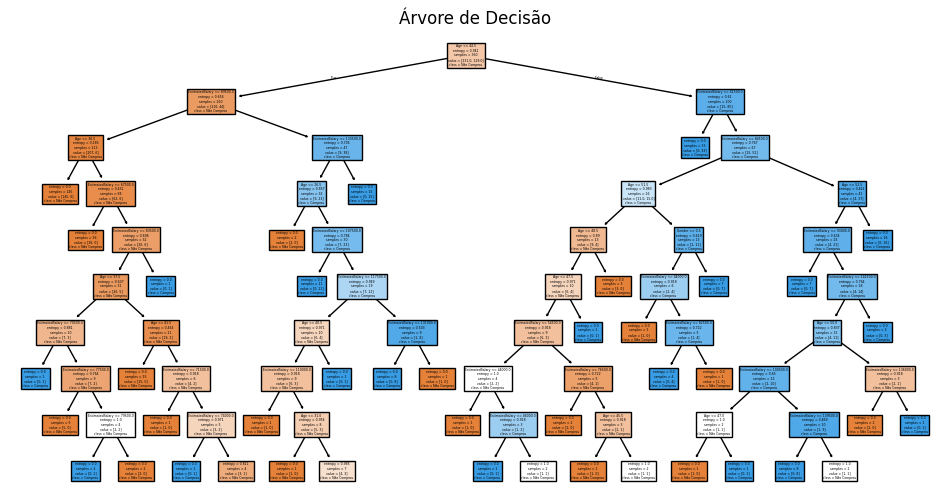

In [8]:
# Visualizar a árvore de decisão
plt.figure(figsize=(12, 6))
plot_tree(modelo, feature_names=X.columns, class_names=["Não Comprou", "Comprou"], filled=True)
plt.title("Árvore de Decisão")
plt.show()